In [1]:
# ============================================================
# EXERCISE 9 - ANOMALY DETECTION / OOD DETECTION
# CELL 1 - SETUP AND PATH CONFIGURATION
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image
from torchvision import transforms, models

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

from sklearn.neighbors import NearestNeighbors

# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("EXERCISE 9 - ANOMALY DETECTION / OOD DETECTION")
print("=" * 70)

print("\nDEVICE")
print("-" * 70)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
else:
    print("GPU: Not available")

# ------------------------------------------------------------
# BASE PATH
# ------------------------------------------------------------

BASE_PATH = r"E:\ML_Safety"

# ------------------------------------------------------------
# DATASET DIRECTORIES
# ------------------------------------------------------------

TRAIN_DIR = os.path.join(
    BASE_PATH,
    "train"
)

TEST_DIR = os.path.join(
    BASE_PATH,
    "test"
)

FOG_DIR = os.path.join(
    BASE_PATH,
    "test-fog"
)

NIGHT_DIR = os.path.join(
    BASE_PATH,
    "test-night"
)

TOWN_DIR = os.path.join(
    BASE_PATH,
    "test-town-01"
)

# ------------------------------------------------------------
# MODEL DIRECTORY
# ------------------------------------------------------------

MODEL_DIR = os.path.join(
    BASE_PATH,
    "model_outputs"
)

# ------------------------------------------------------------
# MODEL PATHS
# ------------------------------------------------------------

PEDESTRIAN_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_pedestrian.pth"
)

TRAFFIC_LIGHT_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_traffic_light.pth"
)

VEHICLE_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "best_vehicle.pth"
)

# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

OOD_RESULTS_DIR = os.path.join(
    BASE_PATH,
    "ood_results"
)

os.makedirs(
    OOD_RESULTS_DIR,
    exist_ok=True
)

# ------------------------------------------------------------
# PRINT PATH CONFIGURATION
# ------------------------------------------------------------

print("\nPATH CONFIGURATION")
print("-" * 70)

print("Base path       :", BASE_PATH)
print("Train directory :", TRAIN_DIR)
print("Test directory  :", TEST_DIR)
print("Fog directory   :", FOG_DIR)
print("Night directory :", NIGHT_DIR)
print("Town directory  :", TOWN_DIR)
print("Model directory :", MODEL_DIR)
print("Output directory:", OOD_RESULTS_DIR)

# ------------------------------------------------------------
# PATH EXISTENCE CHECK
# ------------------------------------------------------------

print("\nDIRECTORY CHECK")
print("-" * 70)

directories = {
    "Train": TRAIN_DIR,
    "Test": TEST_DIR,
    "Fog": FOG_DIR,
    "Night": NIGHT_DIR,
    "Town": TOWN_DIR,
    "Models": MODEL_DIR
}

for name, path in directories.items():
    print(
        f"{name:<10}:",
        "EXISTS" if os.path.exists(path) else "MISSING",
        "->",
        path
    )

# ------------------------------------------------------------
# MODEL FILE CHECK
# ------------------------------------------------------------

print("\nMODEL FILE CHECK")
print("-" * 70)

model_files = {
    "Pedestrian": PEDESTRIAN_MODEL_PATH,
    "Traffic Light": TRAFFIC_LIGHT_MODEL_PATH,
    "Vehicle": VEHICLE_MODEL_PATH
}

for name, path in model_files.items():
    print(
        f"{name:<15}:",
        "EXISTS" if os.path.isfile(path) else "MISSING",
        "->",
        path
    )

# ------------------------------------------------------------
# IMAGE TRANSFORM
# ------------------------------------------------------------

TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("\nIMAGE TRANSFORM")
print("-" * 70)
print(TRANSFORM)

# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 1 COMPLETE")
print("=" * 70)

EXERCISE 9 - ANOMALY DETECTION / OOD DETECTION

DEVICE
----------------------------------------------------------------------
Device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
CUDA version: 12.1

PATH CONFIGURATION
----------------------------------------------------------------------
Base path       : E:\ML_Safety
Train directory : E:\ML_Safety\train
Test directory  : E:\ML_Safety\test
Fog directory   : E:\ML_Safety\test-fog
Night directory : E:\ML_Safety\test-night
Town directory  : E:\ML_Safety\test-town-01
Model directory : E:\ML_Safety\model_outputs
Output directory: E:\ML_Safety\ood_results

DIRECTORY CHECK
----------------------------------------------------------------------
Train     : EXISTS -> E:\ML_Safety\train
Test      : EXISTS -> E:\ML_Safety\test
Fog       : EXISTS -> E:\ML_Safety\test-fog
Night     : EXISTS -> E:\ML_Safety\test-night
Town      : EXISTS -> E:\ML_Safety\test-town-01
Models    : EXISTS -> E:\ML_Safety\model_outputs

MODEL FILE CHECK
----------------

In [2]:
# ============================================================
# EXERCISE 9 - ANOMALY DETECTION / OOD DETECTION
# CELL 2 - LOAD CARLA MODELS
# ============================================================

print("=" * 70)
print("EXERCISE 9 - LOADING CARLA MODELS")
print("=" * 70)


# ============================================================
# MODEL CREATION FUNCTION
# ============================================================

def create_resnet18(num_classes=2):

    model = models.resnet18(weights=None)

    # Replace final fully-connected layer
    model.fc = nn.Linear(
        model.fc.in_features,
        num_classes
    )

    return model


# ============================================================
# MODEL LOADING FUNCTION
# ============================================================

def load_carla_model(model_path, model_name):

    print("\n" + "-" * 60)
    print(f"Loading {model_name}...")
    print("-" * 60)

    if not os.path.isfile(model_path):
        raise FileNotFoundError(
            f"Model file not found:\n{model_path}"
        )

    # Create model architecture
    model = create_resnet18(num_classes=2)

    # Load checkpoint
    checkpoint = torch.load(
        model_path,
        map_location=DEVICE,
        weights_only=False
    )

    # --------------------------------------------------------
    # Handle different checkpoint formats
    # --------------------------------------------------------

    if isinstance(checkpoint, dict):

        if "state_dict" in checkpoint:
            state_dict = checkpoint["state_dict"]

        elif "model_state_dict" in checkpoint:
            state_dict = checkpoint["model_state_dict"]

        elif "model" in checkpoint:
            state_dict = checkpoint["model"]

        else:
            # Assume the dictionary itself is the state dict
            state_dict = checkpoint

    else:
        state_dict = checkpoint

    # --------------------------------------------------------
    # Remove possible "module." prefix
    # --------------------------------------------------------

    cleaned_state_dict = {}

    for key, value in state_dict.items():

        if key.startswith("module."):
            key = key[7:]

        cleaned_state_dict[key] = value

    # --------------------------------------------------------
    # Load weights
    # --------------------------------------------------------

    model.load_state_dict(
        cleaned_state_dict,
        strict=True
    )

    # Move to GPU
    model = model.to(DEVICE)

    # Evaluation mode
    model.eval()

    # --------------------------------------------------------
    # Verification
    # --------------------------------------------------------

    print("Loaded successfully.")
    print("Device:", next(model.parameters()).device)
    print("Evaluation mode:", not model.training)
    print(
        "Trainable parameters:",
        sum(
            p.numel()
            for p in model.parameters()
            if p.requires_grad
        )
    )

    return model


# ============================================================
# LOAD ALL THREE MODELS
# ============================================================

pedestrian_model = load_carla_model(
    PEDESTRIAN_MODEL_PATH,
    "Pedestrian"
)

traffic_light_model = load_carla_model(
    TRAFFIC_LIGHT_MODEL_PATH,
    "Traffic Light"
)

vehicle_model = load_carla_model(
    VEHICLE_MODEL_PATH,
    "Vehicle"
)


# ============================================================
# MODEL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("MODEL SUMMARY")
print("=" * 70)

loaded_models = {
    "Pedestrian": pedestrian_model,
    "Traffic Light": traffic_light_model,
    "Vehicle": vehicle_model
}

for name, model in loaded_models.items():

    parameter_count = sum(
        p.numel()
        for p in model.parameters()
    )

    print(
        f"{name:<15} | "
        f"Device: {next(model.parameters()).device} | "
        f"Parameters: {parameter_count:,}"
    )


# ============================================================
# FINAL CHECK
# ============================================================

print("\n" + "=" * 70)
print("ALL CARLA MODELS LOADED SUCCESSFULLY")
print("=" * 70)

print("\nCELL 2 COMPLETE")
print("=" * 70)

EXERCISE 9 - LOADING CARLA MODELS

------------------------------------------------------------
Loading Pedestrian...
------------------------------------------------------------
Loaded successfully.
Device: cuda:0
Evaluation mode: True
Trainable parameters: 11177538

------------------------------------------------------------
Loading Traffic Light...
------------------------------------------------------------
Loaded successfully.
Device: cuda:0
Evaluation mode: True
Trainable parameters: 11177538

------------------------------------------------------------
Loading Vehicle...
------------------------------------------------------------
Loaded successfully.
Device: cuda:0
Evaluation mode: True
Trainable parameters: 11177538

MODEL SUMMARY
Pedestrian      | Device: cuda:0 | Parameters: 11,177,538
Traffic Light   | Device: cuda:0 | Parameters: 11,177,538
Vehicle         | Device: cuda:0 | Parameters: 11,177,538

ALL CARLA MODELS LOADED SUCCESSFULLY

CELL 2 COMPLETE


In [3]:
# ============================================================
# EXERCISE 9 - ANOMALY DETECTION / OOD DETECTION
# CELL 3 - LOAD AND VERIFY DATASETS
# ============================================================

print("=" * 70)
print("EXERCISE 9 - DATASET VERIFICATION")
print("=" * 70)


# ============================================================
# DATASET CONFIGURATION
# ============================================================

DATASET_CONFIG = {

    "test": {
        "path": TEST_DIR,
        "role": "IN-DISTRIBUTION"
    },

    "test-fog": {
        "path": FOG_DIR,
        "role": "OOD"
    },

    "test-night": {
        "path": NIGHT_DIR,
        "role": "OOD"
    },

    "test-town-01": {
        "path": TOWN_DIR,
        "role": "SEPARATE TOWN ANALYSIS"
    }
}


# ============================================================
# DATASET LOADER
# ============================================================

def load_dataset_metadata(
    dataset_name,
    dataset_path
):

    print("\n" + "-" * 70)
    print(f"LOADING: {dataset_name}")
    print("-" * 70)

    # --------------------------------------------------------
    # Check directory
    # --------------------------------------------------------

    if not os.path.isdir(dataset_path):

        raise FileNotFoundError(
            f"Dataset directory not found:\n{dataset_path}"
        )

    # --------------------------------------------------------
    # Label file
    # --------------------------------------------------------

    label_path = os.path.join(
        dataset_path,
        "labels.feather"
    )

    if not os.path.isfile(label_path):

        raise FileNotFoundError(
            f"Label file not found:\n{label_path}"
        )

    # --------------------------------------------------------
    # Load labels
    # --------------------------------------------------------

    df = pd.read_feather(
        label_path
    )

    # --------------------------------------------------------
    # Image directory
    # --------------------------------------------------------

    rgb_dir = os.path.join(
        dataset_path,
        "rgb-front"
    )

    if not os.path.isdir(rgb_dir):

        raise FileNotFoundError(
            f"RGB directory not found:\n{rgb_dir}"
        )

    # --------------------------------------------------------
    # Build image lookup
    # --------------------------------------------------------

    image_lookup = {}

    for filename in os.listdir(rgb_dir):

        if filename.lower().endswith(
            ".jpg"
        ):

            frame_name = os.path.splitext(
                filename
            )[0]

            image_lookup[
                frame_name
            ] = os.path.join(
                rgb_dir,
                filename
            )

    # --------------------------------------------------------
    # Verify required columns
    # --------------------------------------------------------

    required_columns = [
        "frame",
        "has_traffic_light",
        "has_pedestrian",
        "has_vehicle"
    ]

    missing_columns = [
        col
        for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:

        raise ValueError(
            f"Missing columns in {dataset_name}: "
            f"{missing_columns}"
        )

    # --------------------------------------------------------
    # Add image paths
    # --------------------------------------------------------

    def frame_to_key(frame):

        if isinstance(
            frame,
            (int, np.integer)
        ):

            return f"{int(frame):06d}"

        frame_string = str(
            frame
        ).strip()

        # Handle values such as "000010"
        if frame_string.isdigit():

            return f"{int(frame_string):06d}"

        return frame_string

    df = df.copy()

    df["frame_key"] = df[
        "frame"
    ].apply(
        frame_to_key
    )

    df["image_path"] = df[
        "frame_key"
    ].map(
        image_lookup
    )

    missing_images = df[
        df["image_path"].isna()
    ]

    # --------------------------------------------------------
    # Label distributions
    # --------------------------------------------------------

    pedestrian_positive = int(
        df["has_pedestrian"].astype(bool).sum()
    )

    traffic_positive = int(
        df["has_traffic_light"].astype(bool).sum()
    )

    vehicle_positive = int(
        df["has_vehicle"].astype(bool).sum()
    )

    # --------------------------------------------------------
    # Print results
    # --------------------------------------------------------

    print(
        "Directory:",
        dataset_path
    )

    print(
        "Label file:",
        label_path
    )

    print(
        "Number of labels:",
        len(df)
    )

    print(
        "RGB images found:",
        len(image_lookup)
    )

    print(
        "Missing image paths:",
        len(missing_images)
    )

    print("\nLabel distribution:")

    print(
        f"  Pedestrian    : "
        f"Positive={pedestrian_positive:4d} | "
        f"Negative={len(df)-pedestrian_positive:4d}"
    )

    print(
        f"  Traffic Light : "
        f"Positive={traffic_positive:4d} | "
        f"Negative={len(df)-traffic_positive:4d}"
    )

    print(
        f"  Vehicle       : "
        f"Positive={vehicle_positive:4d} | "
        f"Negative={len(df)-vehicle_positive:4d}"
    )

    # --------------------------------------------------------
    # Verify all images exist
    # --------------------------------------------------------

    if len(missing_images) > 0:

        print("\nWARNING:")
        print(
            missing_images[
                ["frame", "image_path"]
            ].head(10)
        )

    return df


# ============================================================
# LOAD ALL DATASETS
# ============================================================

dataset_dataframes = {}

for dataset_name, config in DATASET_CONFIG.items():

    dataset_dataframes[
        dataset_name
    ] = load_dataset_metadata(
        dataset_name,
        config["path"]
    )


# ============================================================
# DATASET SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

for dataset_name, config in DATASET_CONFIG.items():

    df = dataset_dataframes[
        dataset_name
    ]

    print(
        f"{dataset_name:<15} | "
        f"Role={config['role']:<22} | "
        f"Samples={len(df):4d} | "
        f"Missing images={df['image_path'].isna().sum():4d}"
    )


# ============================================================
# SAMPLE IMAGE PATHS
# ============================================================

print("\n" + "-" * 70)
print("SAMPLE IMAGE LOOKUP")
print("-" * 70)

test_df = dataset_dataframes[
    "test"
]

for _, row in test_df.head(5).iterrows():

    print(
        f"Frame {row['frame_key']} -> "
        f"{row['image_path']}"
    )


print("\n" + "=" * 70)
print("CELL 3 COMPLETE")
print("=" * 70)

EXERCISE 9 - DATASET VERIFICATION

----------------------------------------------------------------------
LOADING: test
----------------------------------------------------------------------
Directory: E:\ML_Safety\test
Label file: E:\ML_Safety\test\labels.feather
Number of labels: 3600
RGB images found: 3600
Missing image paths: 0

Label distribution:
  Pedestrian    : Positive= 706 | Negative=2894
  Traffic Light : Positive=2584 | Negative=1016
  Vehicle       : Positive=2700 | Negative= 900

----------------------------------------------------------------------
LOADING: test-fog
----------------------------------------------------------------------
Directory: E:\ML_Safety\test-fog
Label file: E:\ML_Safety\test-fog\labels.feather
Number of labels: 3600
RGB images found: 3600
Missing image paths: 0

Label distribution:
  Pedestrian    : Positive= 733 | Negative=2867
  Traffic Light : Positive=2626 | Negative= 974
  Vehicle       : Positive=2785 | Negative= 815

-----------------------

EXERCISE 9.4 - VISUALISING THE DISTRIBUTION SHIFT


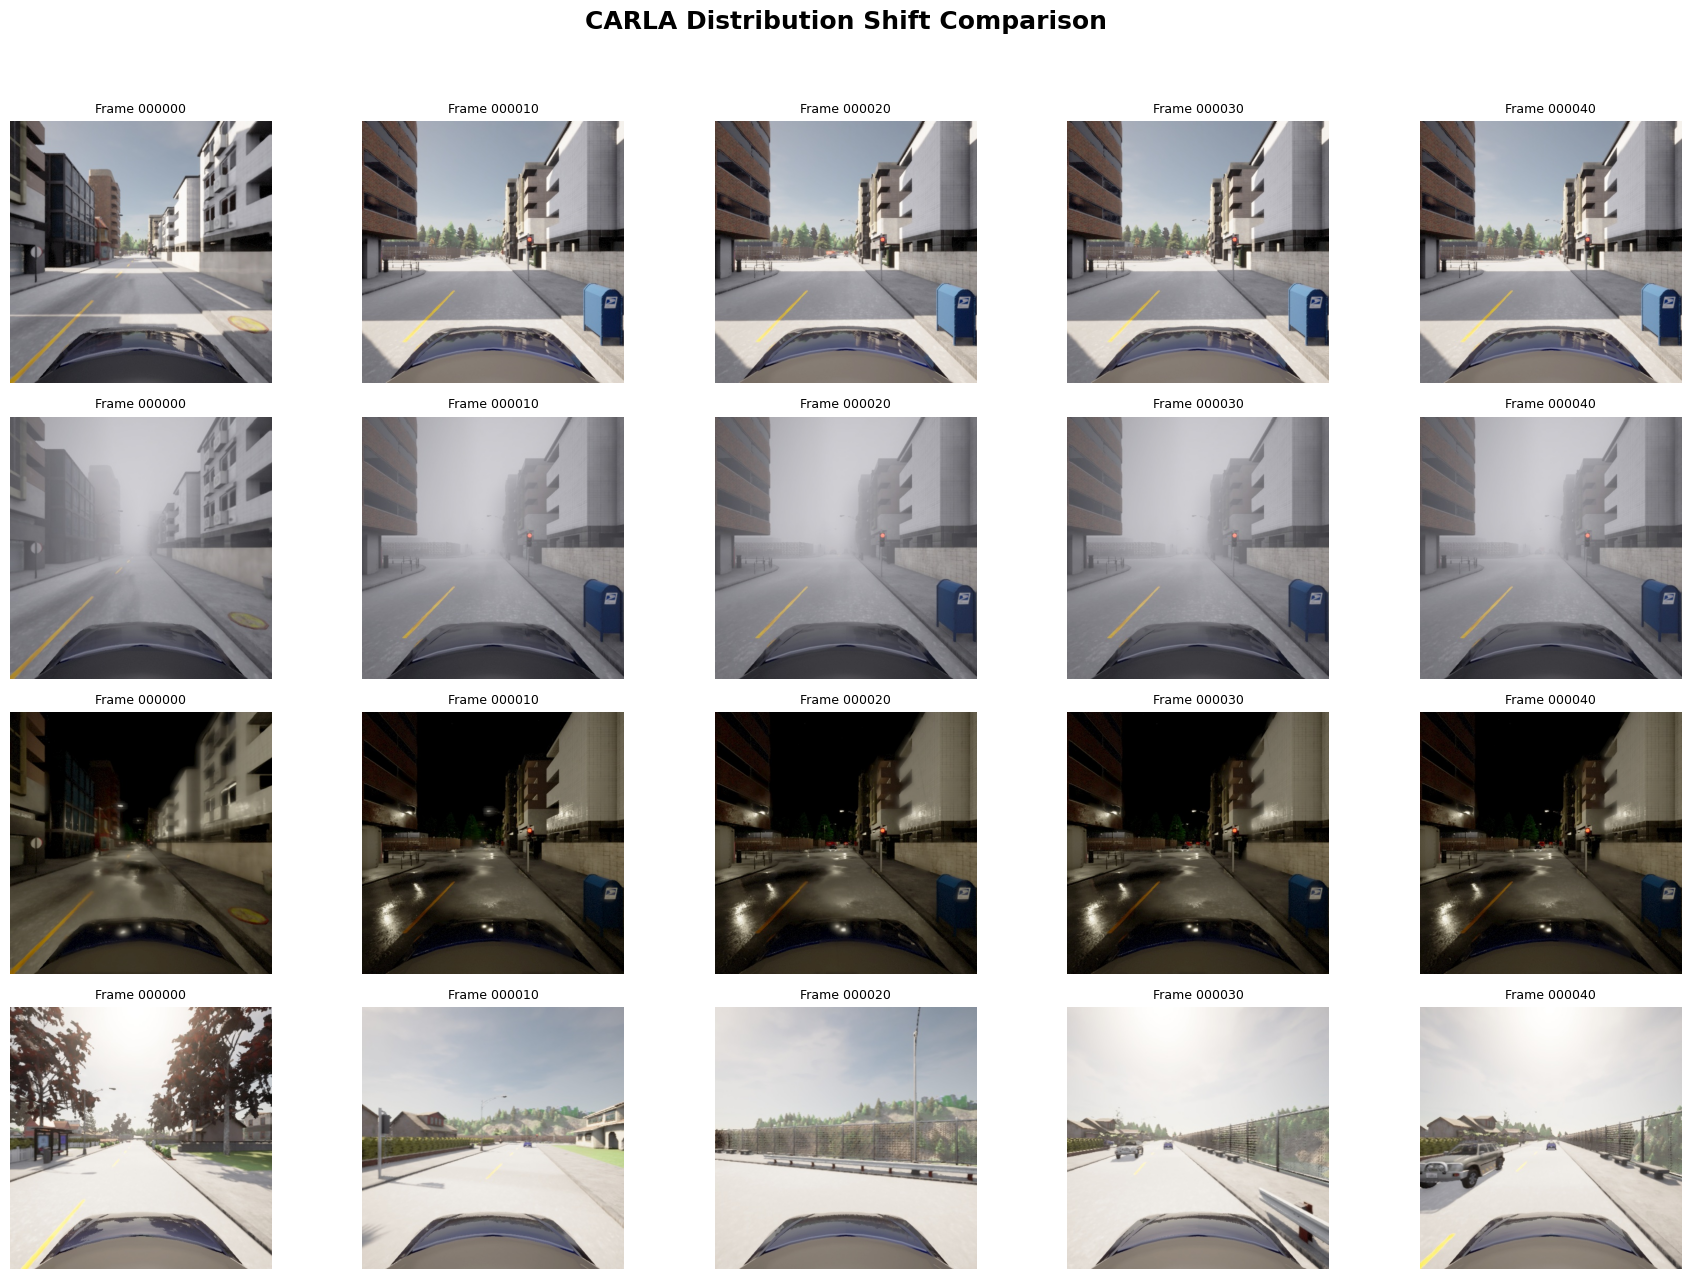


VISUALISATION COMPLETE
Images displayed: 20
Conditions: 4
Saved to: E:\ML_Safety\ood_results\distribution_shift_comparison.png

CELL 4 COMPLETE


In [4]:
# ============================================================
# EXERCISE 9.4
# CELL 4 - VISUALISING DISTRIBUTION SHIFT
# ============================================================

print("=" * 70)
print("EXERCISE 9.4 - VISUALISING THE DISTRIBUTION SHIFT")
print("=" * 70)


# ============================================================
# CONDITIONS TO DISPLAY
# ============================================================

visualization_conditions = [
    ("test", "In-Distribution\nSunny / Daytime"),
    ("test-fog", "OOD\nFog"),
    ("test-night", "OOD\nNight"),
    ("test-town-01", "Different Town")
]


# ============================================================
# NUMBER OF IMAGES
# ============================================================

N_IMAGES = 5


# ============================================================
# CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    len(visualization_conditions),
    N_IMAGES,
    figsize=(18, 13)
)


# ============================================================
# DISPLAY IMAGES
# ============================================================

for row_idx, (condition_name, title) in enumerate(
    visualization_conditions
):

    df = dataset_dataframes[
        condition_name
    ]

    # Select first five images
    selected_rows = df.head(
        N_IMAGES
    )

    for col_idx, (_, row) in enumerate(
        selected_rows.iterrows()
    ):

        image_path = row[
            "image_path"
        ]

        image = Image.open(
            image_path
        ).convert("RGB")

        axes[
            row_idx,
            col_idx
        ].imshow(
            image
        )

        axes[
            row_idx,
            col_idx
        ].axis("off")

        if col_idx == 0:

            axes[
                row_idx,
                col_idx
            ].set_ylabel(
                title,
                fontsize=11,
                fontweight="bold"
            )


        axes[
            row_idx,
            col_idx
        ].set_title(
            f"Frame {row['frame_key']}",
            fontsize=9
        )


# ============================================================
# FIGURE TITLE
# ============================================================

fig.suptitle(
    "CARLA Distribution Shift Comparison",
    fontsize=18,
    fontweight="bold"
)


plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)


# ============================================================
# SAVE FIGURE
# ============================================================

visualization_path = os.path.join(
    OOD_RESULTS_DIR,
    "distribution_shift_comparison.png"
)

plt.savefig(
    visualization_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

plt.close(fig)


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("VISUALISATION COMPLETE")
print("=" * 70)

print(
    "Images displayed:",
    len(visualization_conditions) * N_IMAGES
)

print(
    "Conditions:",
    len(visualization_conditions)
)

print(
    "Saved to:",
    visualization_path
)

print("\n" + "=" * 70)
print("CELL 4 COMPLETE")
print("=" * 70)

EXERCISE 9.4 - MEAN SOFTMAX CONFIDENCE
test            | Samples=3600 | Batches= 57
test-fog        | Samples=3600 | Batches= 57
test-night      | Samples=3600 | Batches= 57
test-town-01    | Samples=3600 | Batches= 57

----------------------------------------------------------------------
MODEL: Pedestrian
----------------------------------------------------------------------
Evaluating test...
Mean confidence: 0.8394
Std confidence : 0.1186
Min confidence : 0.5008
Max confidence : 0.9981
Evaluating test-fog...
Mean confidence: 0.8884
Std confidence : 0.0618
Min confidence : 0.5312
Max confidence : 0.9856
Evaluating test-night...
Mean confidence: 0.7802
Std confidence : 0.0946
Min confidence : 0.5001
Max confidence : 0.9440
Evaluating test-town-01...
Mean confidence: 0.8548
Std confidence : 0.1115
Min confidence : 0.5009
Max confidence : 0.9838

----------------------------------------------------------------------
MODEL: Traffic Light
-------------------------------------------------

,Condition,Model,Mean Confidence,Std Confidence,Min Confidence,Max Confidence
0,test,Pedestrian,0.839419,0.118597,0.500845,0.998117
1,test-fog,Pedestrian,0.888365,0.061809,0.531236,0.985627
2,test-night,Pedestrian,0.780237,0.094642,0.500101,0.943969
3,test-town-01,Pedestrian,0.854844,0.111453,0.500928,0.983829
4,test,Traffic Light,0.983358,0.059288,0.511230,1.000000
5,test-fog,Traffic Light,0.860384,0.143656,0.500046,1.000000
6,test-night,Traffic Light,0.987941,0.043241,0.548456,1.000000
7,test-town-01,Traffic Light,0.901731,0.135909,0.501086,1.000000
8,test,Vehicle,0.916806,0.129287,0.500550,0.999994
9,test-fog,Vehicle,0.852640,0.125245,0.500493,0.999704



MEAN CONFIDENCE BY CONDITION


Model,Pedestrian,Traffic Light,Vehicle
Condition,,,
test,0.839419,0.983358,0.916806
test-fog,0.888365,0.860384,0.852640
test-night,0.780237,0.987941,0.832873
test-town-01,0.854844,0.901731,0.884762


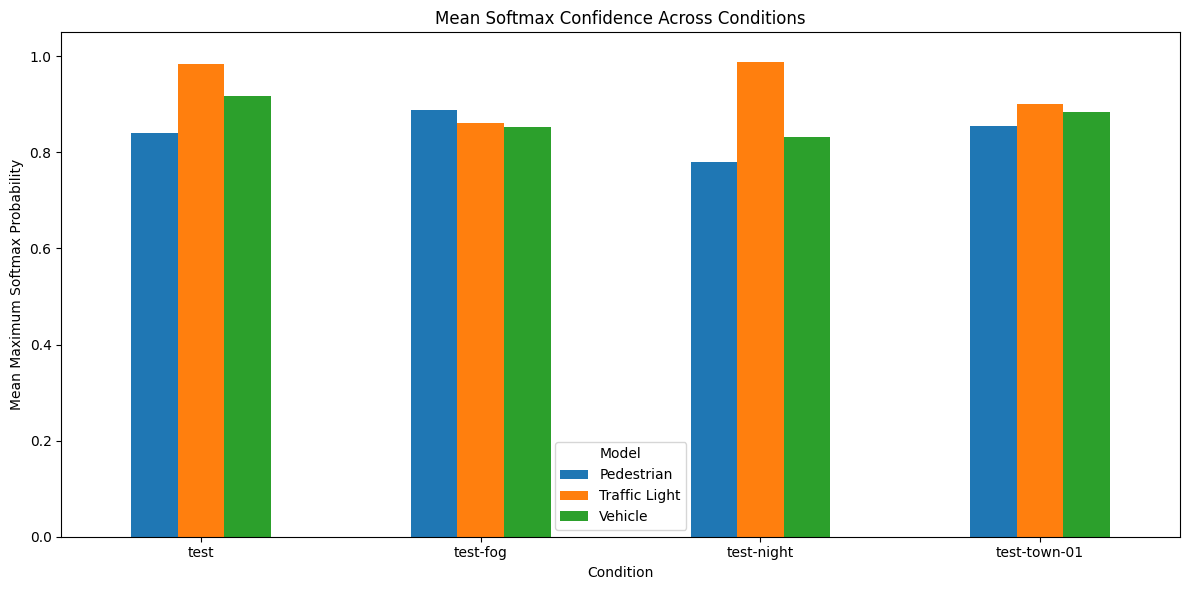


CONFIDENCE ANALYSIS COMPLETE
CSV saved to: E:\ML_Safety\ood_results\mean_softmax_confidence.csv
Plot saved to: E:\ML_Safety\ood_results\mean_softmax_confidence.png

CELL 5 COMPLETE


In [5]:
# ============================================================
# EXERCISE 9.4 - MEAN SOFTMAX CONFIDENCE
# CELL 5
# ============================================================

print("=" * 70)
print("EXERCISE 9.4 - MEAN SOFTMAX CONFIDENCE")
print("=" * 70)


# ============================================================
# DATASET CLASS
# ============================================================

class OODImageDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.dataframe = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["image_path"]

        image = Image.open(
            image_path
        ).convert("RGB")

        image = self.transform(
            image
        )

        return image


# ============================================================
# CREATE DATALOADERS
# ============================================================

BATCH_SIZE = 64

condition_loaders = {}

for condition_name, df in dataset_dataframes.items():

    dataset = OODImageDataset(
        dataframe=df,
        transform=TRANSFORM
    )

    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available()
    )

    condition_loaders[
        condition_name
    ] = loader

    print(
        f"{condition_name:<15} | "
        f"Samples={len(dataset):4d} | "
        f"Batches={len(loader):3d}"
    )


# ============================================================
# CONFIDENCE FUNCTION
# ============================================================

def calculate_mean_softmax_confidence(
    model,
    dataloader
):

    model.eval()

    all_confidences = []

    with torch.no_grad():

        for images in dataloader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            logits = model(
                images
            )

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            # Maximum probability = model confidence
            confidence, _ = torch.max(
                probabilities,
                dim=1
            )

            all_confidences.append(
                confidence.cpu()
            )

    all_confidences = torch.cat(
        all_confidences
    )

    return {
        "mean": float(
            all_confidences.mean()
        ),
        "std": float(
            all_confidences.std()
        ),
        "min": float(
            all_confidences.min()
        ),
        "max": float(
            all_confidences.max()
        )
    }


# ============================================================
# MODELS
# ============================================================

models_for_ood = {

    "Pedestrian": pedestrian_model,

    "Traffic Light": traffic_light_model,

    "Vehicle": vehicle_model
}


# ============================================================
# CALCULATE CONFIDENCE
# ============================================================

confidence_results = []


for model_name, model in models_for_ood.items():

    print("\n" + "-" * 70)
    print(
        f"MODEL: {model_name}"
    )
    print("-" * 70)

    for condition_name in [
        "test",
        "test-fog",
        "test-night",
        "test-town-01"
    ]:

        print(
            f"Evaluating {condition_name}..."
        )

        statistics = calculate_mean_softmax_confidence(
            model,
            condition_loaders[
                condition_name
            ]
        )

        confidence_results.append([
            condition_name,
            model_name,
            statistics["mean"],
            statistics["std"],
            statistics["min"],
            statistics["max"]
        ])

        print(
            f"Mean confidence: "
            f"{statistics['mean']:.4f}"
        )

        print(
            f"Std confidence : "
            f"{statistics['std']:.4f}"
        )

        print(
            f"Min confidence : "
            f"{statistics['min']:.4f}"
        )

        print(
            f"Max confidence : "
            f"{statistics['max']:.4f}"
        )


# ============================================================
# CREATE RESULTS DATAFRAME
# ============================================================

confidence_df = pd.DataFrame(
    confidence_results,
    columns=[
        "Condition",
        "Model",
        "Mean Confidence",
        "Std Confidence",
        "Min Confidence",
        "Max Confidence"
    ]
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 70)
print("MEAN SOFTMAX CONFIDENCE SUMMARY")
print("=" * 70)

display(
    confidence_df
)


# ============================================================
# SAVE RESULTS
# ============================================================

confidence_path = os.path.join(
    OOD_RESULTS_DIR,
    "mean_softmax_confidence.csv"
)

confidence_df.to_csv(
    confidence_path,
    index=False
)


# ============================================================
# PIVOT TABLE
# ============================================================

confidence_pivot = confidence_df.pivot(
    index="Condition",
    columns="Model",
    values="Mean Confidence"
)

print("\n" + "=" * 70)
print("MEAN CONFIDENCE BY CONDITION")
print("=" * 70)

display(
    confidence_pivot
)


# ============================================================
# PLOT
# ============================================================

ax = confidence_pivot.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title(
    "Mean Softmax Confidence Across Conditions"
)

ax.set_xlabel(
    "Condition"
)

ax.set_ylabel(
    "Mean Maximum Softmax Probability"
)

ax.set_ylim(
    0,
    1.05
)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Model"
)

plt.tight_layout()


confidence_plot_path = os.path.join(
    OOD_RESULTS_DIR,
    "mean_softmax_confidence.png"
)

plt.savefig(
    confidence_plot_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 70)
print("CONFIDENCE ANALYSIS COMPLETE")
print("=" * 70)

print(
    "CSV saved to:",
    confidence_path
)

print(
    "Plot saved to:",
    confidence_plot_path
)

print("\nCELL 5 COMPLETE")
print("=" * 70)

EXERCISE 9.4 - MSP OOD DETECTION

----------------------------------------------------------------------
MODEL: Pedestrian
----------------------------------------------------------------------
Calculating MSP: test...
Mean MSP   : 0.8394
Median MSP : 0.8744
Min MSP    : 0.5008
Max MSP    : 0.9981
Calculating MSP: test-fog...
Mean MSP   : 0.8884
Median MSP : 0.9003
Min MSP    : 0.5312
Max MSP    : 0.9856
Calculating MSP: test-night...
Mean MSP   : 0.7802
Median MSP : 0.8028
Min MSP    : 0.5001
Max MSP    : 0.9440
Calculating MSP: test-town-01...
Mean MSP   : 0.8548
Median MSP : 0.8929
Min MSP    : 0.5009
Max MSP    : 0.9838

----------------------------------------------------------------------
MODEL: Traffic Light
----------------------------------------------------------------------
Calculating MSP: test...
Mean MSP   : 0.9834
Median MSP : 0.9993
Min MSP    : 0.5112
Max MSP    : 1.0000
Calculating MSP: test-fog...
Mean MSP   : 0.8604
Median MSP : 0.9207
Min MSP    : 0.5000
Max MSP   

,Model,ID Condition,OOD Condition,ID Mean MSP,OOD Mean MSP,ID Median MSP,OOD Median MSP,AUROC
0,Pedestrian,test,test-fog,0.839419,0.888365,0.874411,0.900310,0.404142
1,Pedestrian,test,test-night,0.839419,0.780237,0.874411,0.802812,0.682292
2,Traffic Light,test,test-fog,0.983358,0.860384,0.999350,0.920709,0.884590
3,Traffic Light,test,test-night,0.983358,0.987941,0.999350,0.999524,0.477319
4,Vehicle,test,test-fog,0.916807,0.852640,0.987472,0.889258,0.734737
5,Vehicle,test,test-night,0.916807,0.832873,0.987472,0.877328,0.735181


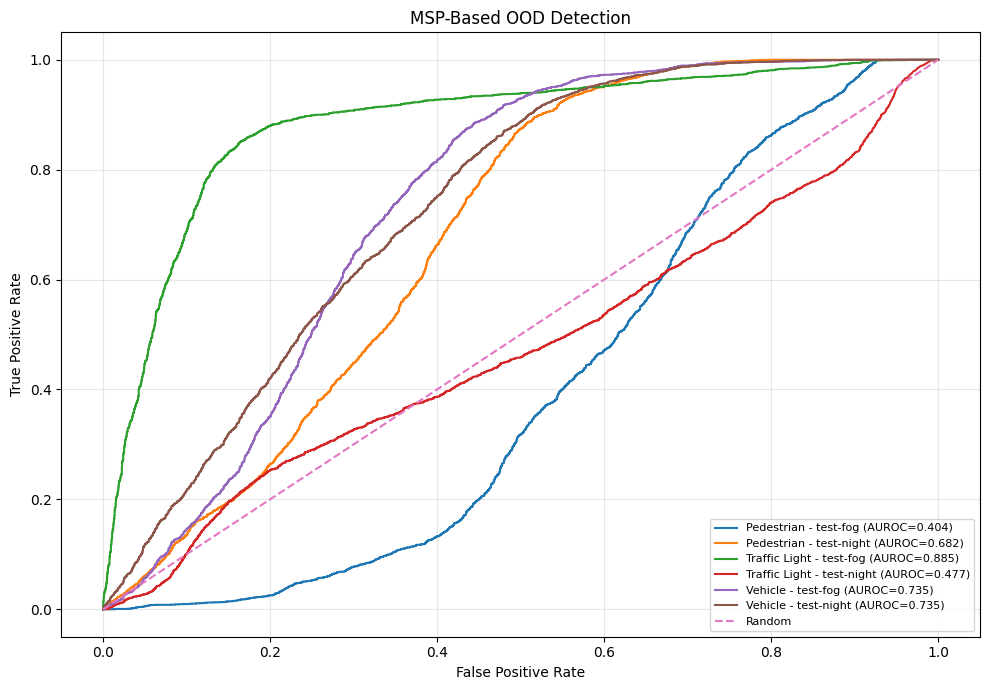


MSP OOD DETECTION COMPLETE
Results saved to: E:\ML_Safety\ood_results\msp_ood_results.csv
ROC plot saved to: E:\ML_Safety\ood_results\msp_ood_roc_curves.png

CELL 6 COMPLETE


In [6]:
# ============================================================
# EXERCISE 9.4 - MSP OOD DETECTION
# CELL 6
# ============================================================

print("=" * 70)
print("EXERCISE 9.4 - MSP OOD DETECTION")
print("=" * 70)


# ============================================================
# IMPORTS
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    roc_curve
)


# ============================================================
# MSP SCORE FUNCTION
# ============================================================

def calculate_msp_scores(
    model,
    dataloader
):

    model.eval()

    all_msp = []

    with torch.no_grad():

        for images in dataloader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            logits = model(
                images
            )

            probabilities = torch.softmax(
                logits,
                dim=1
            )

            # Maximum Softmax Probability
            msp, _ = torch.max(
                probabilities,
                dim=1
            )

            all_msp.append(
                msp.cpu()
            )

    all_msp = torch.cat(
        all_msp
    ).numpy()

    return all_msp


# ============================================================
# CALCULATE MSP FOR ALL CONDITIONS
# ============================================================

msp_scores = {}


for model_name, model in models_for_ood.items():

    print("\n" + "-" * 70)
    print(
        f"MODEL: {model_name}"
    )
    print("-" * 70)

    msp_scores[
        model_name
    ] = {}

    for condition_name in [
        "test",
        "test-fog",
        "test-night",
        "test-town-01"
    ]:

        print(
            f"Calculating MSP: "
            f"{condition_name}..."
        )

        scores = calculate_msp_scores(
            model,
            condition_loaders[
                condition_name
            ]
        )

        msp_scores[
            model_name
        ][condition_name] = scores

        print(
            f"Mean MSP   : "
            f"{np.mean(scores):.4f}"
        )

        print(
            f"Median MSP : "
            f"{np.median(scores):.4f}"
        )

        print(
            f"Min MSP    : "
            f"{np.min(scores):.4f}"
        )

        print(
            f"Max MSP    : "
            f"{np.max(scores):.4f}"
        )


# ============================================================
# OOD DETECTION USING MSP
# ============================================================
#
# Important:
#
# Higher MSP = more ID-like
# Lower MSP  = more OOD-like
#
# Therefore we use NEGATIVE MSP as the OOD score.
#
# OOD label:
# 0 = ID
# 1 = OOD
#
# ============================================================

ood_results = []


for model_name in models_for_ood.keys():

    print("\n" + "=" * 70)
    print(
        f"OOD DETECTION: {model_name}"
    )
    print("=" * 70)

    id_scores = msp_scores[
        model_name
    ]["test"]

    for ood_condition in [
        "test-fog",
        "test-night"
    ]:

        ood_scores = msp_scores[
            model_name
        ][ood_condition]

        # ----------------------------------------------------
        # Labels
        # ----------------------------------------------------

        y_true = np.concatenate([
            np.zeros(
                len(id_scores),
                dtype=np.int64
            ),
            np.ones(
                len(ood_scores),
                dtype=np.int64
            )
        ])

        # ----------------------------------------------------
        # MSP is high for ID.
        # Negative MSP is therefore high for OOD.
        # ----------------------------------------------------

        detection_scores = np.concatenate([
            -id_scores,
            -ood_scores
        ])

        # ----------------------------------------------------
        # AUROC
        # ----------------------------------------------------

        auroc = roc_auc_score(
            y_true,
            detection_scores
        )

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        id_mean = np.mean(
            id_scores
        )

        ood_mean = np.mean(
            ood_scores
        )

        id_median = np.median(
            id_scores
        )

        ood_median = np.median(
            ood_scores
        )

        print(
            f"\nID condition : test"
        )

        print(
            f"OOD condition: {ood_condition}"
        )

        print(
            f"ID mean MSP  : {id_mean:.4f}"
        )

        print(
            f"OOD mean MSP : {ood_mean:.4f}"
        )

        print(
            f"ID median MSP: {id_median:.4f}"
        )

        print(
            f"OOD median MSP: {ood_median:.4f}"
        )

        print(
            f"AUROC        : {auroc:.4f}"
        )

        ood_results.append([
            model_name,
            "test",
            ood_condition,
            id_mean,
            ood_mean,
            id_median,
            ood_median,
            auroc
        ])


# ============================================================
# RESULTS DATAFRAME
# ============================================================

msp_ood_df = pd.DataFrame(
    ood_results,
    columns=[
        "Model",
        "ID Condition",
        "OOD Condition",
        "ID Mean MSP",
        "OOD Mean MSP",
        "ID Median MSP",
        "OOD Median MSP",
        "AUROC"
    ]
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 70)
print("MSP OOD DETECTION SUMMARY")
print("=" * 70)

display(
    msp_ood_df
)


# ============================================================
# SAVE RESULTS
# ============================================================

msp_ood_path = os.path.join(
    OOD_RESULTS_DIR,
    "msp_ood_results.csv"
)

msp_ood_df.to_csv(
    msp_ood_path,
    index=False
)


# ============================================================
# ROC CURVES
# ============================================================

plt.figure(
    figsize=(10, 7)
)

for model_name in models_for_ood.keys():

    for ood_condition in [
        "test-fog",
        "test-night"
    ]:

        id_scores = msp_scores[
            model_name
        ]["test"]

        ood_scores = msp_scores[
            model_name
        ][ood_condition]

        y_true = np.concatenate([
            np.zeros(
                len(id_scores),
                dtype=np.int64
            ),
            np.ones(
                len(ood_scores),
                dtype=np.int64
            )
        ])

        detection_scores = np.concatenate([
            -id_scores,
            -ood_scores
        ])

        fpr, tpr, _ = roc_curve(
            y_true,
            detection_scores
        )

        auroc = roc_auc_score(
            y_true,
            detection_scores
        )

        plt.plot(
            fpr,
            tpr,
            label=(
                f"{model_name} - "
                f"{ood_condition} "
                f"(AUROC={auroc:.3f})"
            )
        )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "MSP-Based OOD Detection"
)

plt.legend(
    fontsize=8
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()


roc_path = os.path.join(
    OOD_RESULTS_DIR,
    "msp_ood_roc_curves.png"
)

plt.savefig(
    roc_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 70)
print("MSP OOD DETECTION COMPLETE")
print("=" * 70)

print(
    "Results saved to:",
    msp_ood_path
)

print(
    "ROC plot saved to:",
    roc_path
)

print("\nCELL 6 COMPLETE")
print("=" * 70)

EXERCISE 9.6 - MSP SCORE DISTRIBUTIONS

----------------------------------------------------------------------
MODEL: Pedestrian
----------------------------------------------------------------------


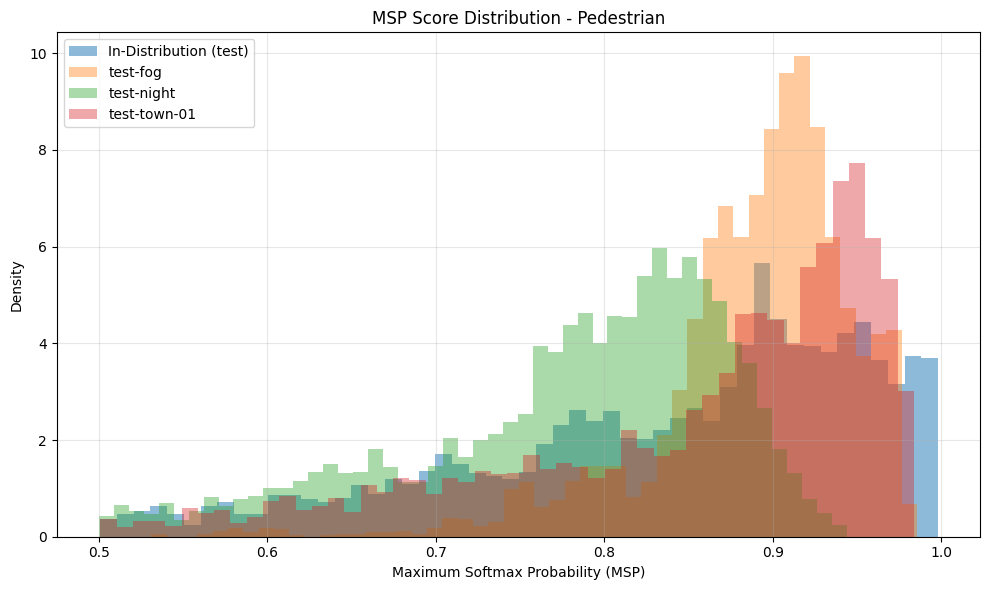

Saved: E:\ML_Safety\ood_results\pedestrian_msp_distribution.png

----------------------------------------------------------------------
MODEL: Traffic Light
----------------------------------------------------------------------


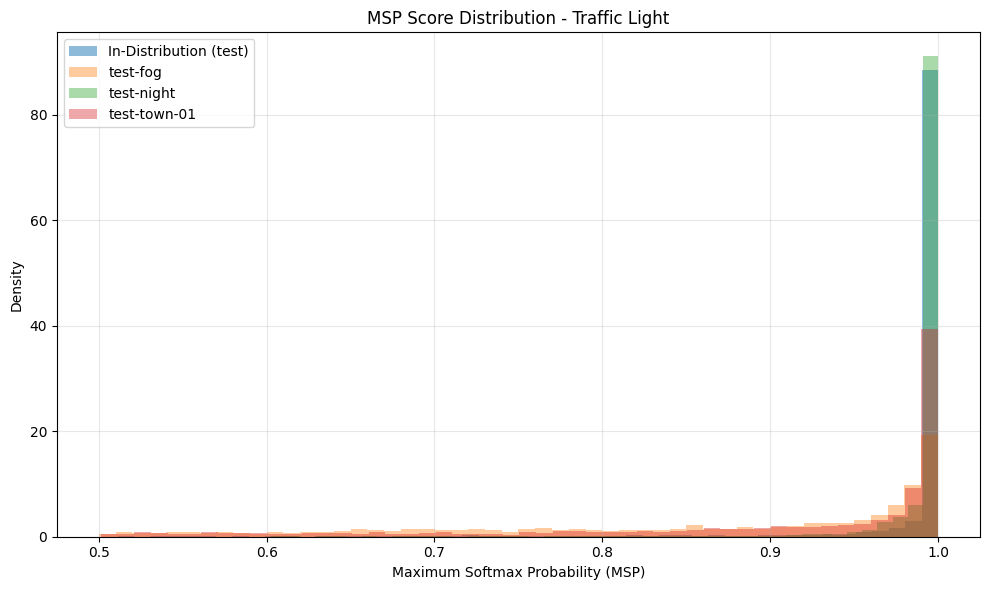

Saved: E:\ML_Safety\ood_results\traffic_light_msp_distribution.png

----------------------------------------------------------------------
MODEL: Vehicle
----------------------------------------------------------------------


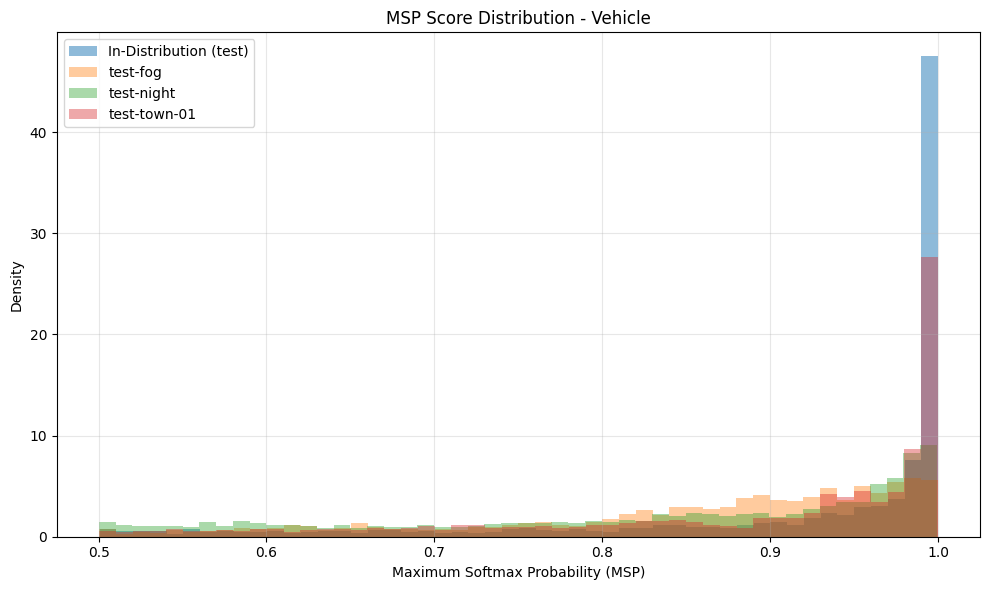

Saved: E:\ML_Safety\ood_results\vehicle_msp_distribution.png

CREATING COMBINED MSP DISTRIBUTION


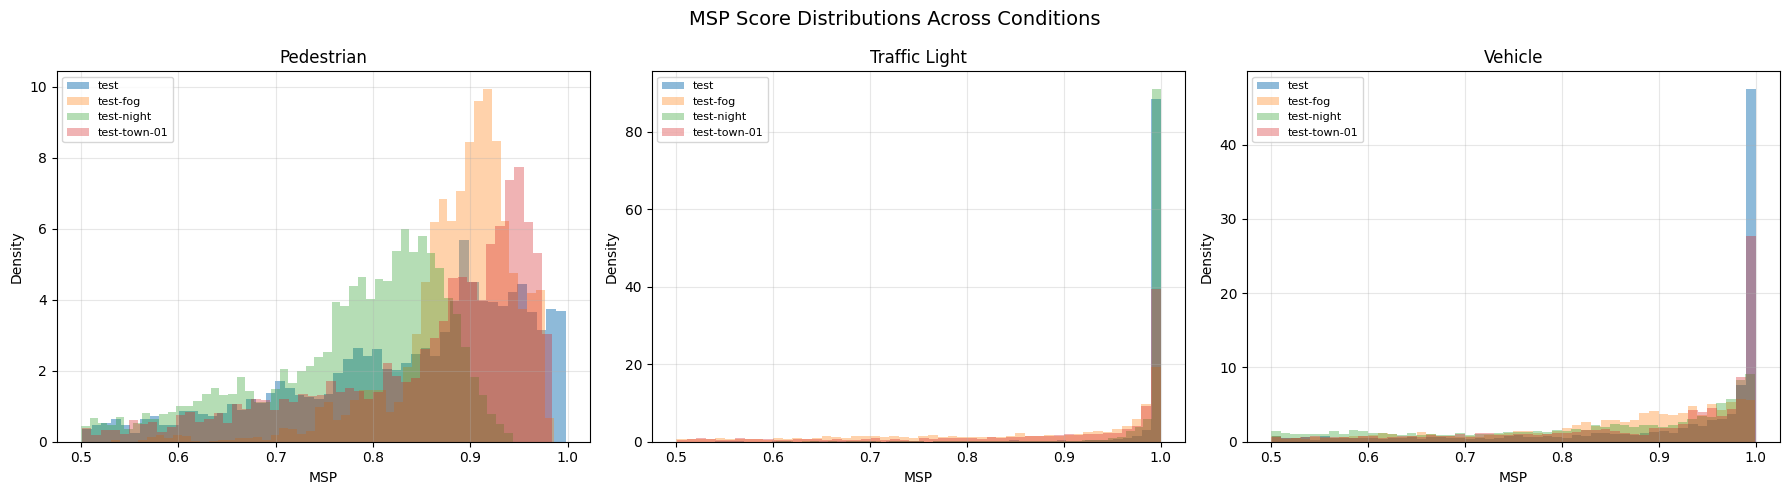


MSP DISTRIBUTION ANALYSIS COMPLETE
Combined plot saved to: E:\ML_Safety\ood_results\msp_distribution_comparison.png
Individual model plots saved to: E:\ML_Safety\ood_results

CELL 7 COMPLETE


In [7]:
# ============================================================
# EXERCISE 9.6 - MSP SCORE DISTRIBUTIONS
# CELL 7
# ============================================================

print("=" * 70)
print("EXERCISE 9.6 - MSP SCORE DISTRIBUTIONS")
print("=" * 70)


# ============================================================
# CREATE OUTPUT DIRECTORY
# ============================================================

os.makedirs(
    OOD_RESULTS_DIR,
    exist_ok=True
)


# ============================================================
# CONDITIONS
# ============================================================

id_condition = "test"

ood_conditions = [
    "test-fog",
    "test-night",
    "test-town-01"
]


# ============================================================
# GENERATE DISTRIBUTION PLOTS
# ============================================================

for model_name in models_for_ood.keys():

    print("\n" + "-" * 70)
    print(
        f"MODEL: {model_name}"
    )
    print("-" * 70)

    plt.figure(
        figsize=(10, 6)
    )

    # --------------------------------------------------------
    # In-distribution scores
    # --------------------------------------------------------

    id_scores = msp_scores[
        model_name
    ][id_condition]

    plt.hist(
        id_scores,
        bins=50,
        alpha=0.5,
        label="In-Distribution (test)",
        density=True
    )

    # --------------------------------------------------------
    # OOD scores
    # --------------------------------------------------------

    for ood_condition in ood_conditions:

        scores = msp_scores[
            model_name
        ][ood_condition]

        plt.hist(
            scores,
            bins=50,
            alpha=0.4,
            label=ood_condition,
            density=True
        )

    # --------------------------------------------------------
    # Plot formatting
    # --------------------------------------------------------

    plt.xlabel(
        "Maximum Softmax Probability (MSP)"
    )

    plt.ylabel(
        "Density"
    )

    plt.title(
        f"MSP Score Distribution - {model_name}"
    )

    plt.legend()

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    output_path = os.path.join(
        OOD_RESULTS_DIR,
        f"{model_name.lower().replace(' ', '_')}_msp_distribution.png"
    )

    plt.savefig(
        output_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    print(
        "Saved:",
        output_path
    )


# ============================================================
# COMBINED DISTRIBUTION COMPARISON
# ============================================================

print("\n" + "=" * 70)
print("CREATING COMBINED MSP DISTRIBUTION")
print("=" * 70)


fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)


for ax, model_name in zip(
    axes,
    models_for_ood.keys()
):

    # --------------------------------------------------------
    # ID
    # --------------------------------------------------------

    id_scores = msp_scores[
        model_name
    ][id_condition]

    ax.hist(
        id_scores,
        bins=50,
        alpha=0.5,
        label="test",
        density=True
    )

    # --------------------------------------------------------
    # OOD
    # --------------------------------------------------------

    for ood_condition in ood_conditions:

        scores = msp_scores[
            model_name
        ][ood_condition]

        ax.hist(
            scores,
            bins=50,
            alpha=0.35,
            label=ood_condition,
            density=True
        )

    ax.set_title(
        model_name
    )

    ax.set_xlabel(
        "MSP"
    )

    ax.set_ylabel(
        "Density"
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend(
        fontsize=8
    )


fig.suptitle(
    "MSP Score Distributions Across Conditions",
    fontsize=14
)

plt.tight_layout()


combined_path = os.path.join(
    OOD_RESULTS_DIR,
    "msp_distribution_comparison.png"
)

plt.savefig(
    combined_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

plt.close()


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 70)
print("MSP DISTRIBUTION ANALYSIS COMPLETE")
print("=" * 70)

print(
    "Combined plot saved to:",
    combined_path
)

print(
    "Individual model plots saved to:",
    OOD_RESULTS_DIR
)

print("\nCELL 7 COMPLETE")
print("=" * 70)

In [10]:
# ============================================================
# EXERCISE 9.7 - DEEP FEATURE EXTRACTION
# CELL 8
# ============================================================

print("=" * 70)
print("EXERCISE 9.7 - DEEP FEATURE EXTRACTION")
print("=" * 70)


# ============================================================
# IMPORTS
# ============================================================

import os
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms


# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ============================================================
# CONFIGURATION
# ============================================================

FEATURE_MODEL_NAME = "Traffic Light"

TRAIN_FEATURE_DIR = TRAIN_DIR

CONDITION_DIRS = {
    "test": TEST_DIR,
    "test-fog": FOG_DIR,
    "test-night": NIGHT_DIR,
    "test-town-01": TOWN_DIR
}


# ============================================================
# IMAGE TRANSFORM
# ============================================================

feature_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("\nImage transform:")
print(feature_transform)


# ============================================================
# DATASET CLASS
# ============================================================

class FeatureImageDataset(Dataset):

    def __init__(
        self,
        image_dir,
        transform=None
    ):

        self.image_dir = image_dir
        self.transform = transform

        rgb_dir = os.path.join(
            image_dir,
            "rgb-front"
        )

        self.image_paths = sorted([
            os.path.join(
                rgb_dir,
                filename
            )
            for filename in os.listdir(rgb_dir)
            if filename.lower().endswith(
                (".jpg", ".jpeg", ".png")
            )
        ])

    def __len__(self):

        return len(
            self.image_paths
        )

    def __getitem__(self, index):

        image_path = self.image_paths[index]

        image = Image.open(
            image_path
        ).convert("RGB")

        if self.transform is not None:

            image = self.transform(
                image
            )

        return image


# ============================================================
# LOAD MODEL
# ============================================================

print("\n" + "-" * 70)
print("LOADING FEATURE EXTRACTION MODEL")
print("-" * 70)

model = models_for_ood[
    FEATURE_MODEL_NAME
]

model = model.to(device)

model.eval()

print(
    "Model:",
    FEATURE_MODEL_NAME
)

print(
    "Device:",
    next(model.parameters()).device
)

print(
    "Evaluation mode:",
    not model.training
)


# ============================================================
# CREATE FEATURE EXTRACTOR
# ============================================================

print("\n" + "-" * 70)
print("CREATING FEATURE EXTRACTOR")
print("-" * 70)

# Remove the final classification layer.
#
# ResNet-18:
#
# Image
#   ↓
# Convolutional layers
#   ↓
# Feature maps
#   ↓
# Adaptive Average Pool
#   ↓
# 512-dimensional feature vector
#   ↓
# FC classification layer
#
# We remove the FC layer.

feature_extractor = nn.Sequential(
    *list(model.children())[:-1]
)

feature_extractor = feature_extractor.to(
    device
)

feature_extractor.eval()

print(
    "Final classification layer removed."
)


# ============================================================
# VERIFY FEATURE DIMENSION
# ============================================================

print("\n" + "-" * 70)
print("FEATURE DIMENSION CHECK")
print("-" * 70)

dummy_input = torch.randn(
    1,
    3,
    224,
    224
).to(device)

with torch.no_grad():

    dummy_features = feature_extractor(
        dummy_input
    )

print(
    "Raw feature shape:",
    tuple(dummy_features.shape)
)

dummy_features = torch.flatten(
    dummy_features,
    start_dim=1
)

print(
    "Flattened feature shape:",
    tuple(dummy_features.shape)
)


# ============================================================
# FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_features(
    image_dir,
    batch_size=128
):

    dataset = FeatureImageDataset(
        image_dir=image_dir,
        transform=feature_transform
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=(
            device.type == "cuda"
        )
    )

    all_features = []

    feature_extractor.eval()

    with torch.no_grad():

        for batch in loader:

            batch = batch.to(
                device,
                non_blocking=True
            )

            features = feature_extractor(
                batch
            )

            features = torch.flatten(
                features,
                start_dim=1
            )

            features = features.cpu().numpy()

            all_features.append(
                features
            )

    features = np.concatenate(
        all_features,
        axis=0
    )

    return features


# ============================================================
# EXTRACT TRAINING FEATURES
# ============================================================

print("\n" + "=" * 70)
print("EXTRACTING TRAINING FEATURES")
print("=" * 70)

train_features = extract_features(
    TRAIN_FEATURE_DIR
)

print(
    "Training feature shape:",
    train_features.shape
)


# ============================================================
# EXTRACT FEATURES FOR ALL CONDITIONS
# ============================================================

condition_features = {}

for condition, directory in CONDITION_DIRS.items():

    print("\n" + "-" * 70)
    print(
        f"EXTRACTING FEATURES: {condition}"
    )
    print("-" * 70)

    features = extract_features(
        directory
    )

    condition_features[
        condition
    ] = features

    print(
        f"{condition:15s} -> "
        f"{features.shape}"
    )


# ============================================================
# FEATURE EXTRACTION SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FEATURE EXTRACTION SUMMARY")
print("=" * 70)

print(
    f"{'Dataset':20s} | "
    f"{'Samples':>8s} | "
    f"{'Features':>8s}"
)

print("-" * 70)

print(
    f"{'Training':20s} | "
    f"{len(train_features):8d} | "
    f"{train_features.shape[1]:8d}"
)

for condition, features in condition_features.items():

    print(
        f"{condition:20s} | "
        f"{len(features):8d} | "
        f"{features.shape[1]:8d}"
    )


# ============================================================
# SAVE FEATURES
# ============================================================

feature_output_dir = os.path.join(
    OOD_RESULTS_DIR,
    "features"
)

os.makedirs(
    feature_output_dir,
    exist_ok=True
)


np.save(
    os.path.join(
        feature_output_dir,
        "traffic_light_train_features.npy"
    ),
    train_features
)


for condition, features in condition_features.items():

    np.save(
        os.path.join(
            feature_output_dir,
            f"traffic_light_{condition}_features.npy"
        ),
        features
    )


# ============================================================
# COMPLETE
# ============================================================

print("\n" + "=" * 70)
print("DEEP FEATURE EXTRACTION COMPLETE")
print("=" * 70)

print(
    "Feature output directory:",
    feature_output_dir
)

print(
    "Training features:",
    train_features.shape
)

print("\nCELL 8 COMPLETE")
print("=" * 70)

EXERCISE 9.7 - DEEP FEATURE EXTRACTION

Device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU

Image transform:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

----------------------------------------------------------------------
LOADING FEATURE EXTRACTION MODEL
----------------------------------------------------------------------
Model: Traffic Light
Device: cuda:0
Evaluation mode: True

----------------------------------------------------------------------
CREATING FEATURE EXTRACTOR
----------------------------------------------------------------------
Final classification layer removed.

----------------------------------------------------------------------
FEATURE DIMENSION CHECK
----------------------------------------------------------------------
Raw feature shape: (1, 512, 1, 1)
Flattened feature shape: (1, 512)

EXTRACTING TRAINING FEATURES
Tra

In [11]:
# ============================================================
# EXERCISE 9.7 - k-NN DEEP FEATURE OOD SCORE
# CELL 9
# ============================================================

print("=" * 70)
print("EXERCISE 9.7 - k-NN DEEP FEATURE OOD SCORE")
print("=" * 70)


# ============================================================
# IMPORTS
# ============================================================

import os
import numpy as np
import pandas as pd

from sklearn.neighbors import NearestNeighbors


# ============================================================
# CONFIGURATION
# ============================================================

K = 5

print("\n" + "-" * 70)
print("k-NN CONFIGURATION")
print("-" * 70)

print("Number of nearest neighbours:", K)
print("Training features:", train_features.shape)


# ============================================================
# NORMALIZE FEATURES
# ============================================================

print("\n" + "-" * 70)
print("NORMALIZING FEATURES")
print("-" * 70)

def l2_normalize(features):

    norms = np.linalg.norm(
        features,
        axis=1,
        keepdims=True
    )

    norms = np.maximum(
        norms,
        1e-12
    )

    return features / norms


train_features_norm = l2_normalize(
    train_features
)

condition_features_norm = {}

for condition, features in condition_features.items():

    condition_features_norm[
        condition
    ] = l2_normalize(
        features
    )


print(
    "Training normalized shape:",
    train_features_norm.shape
)

for condition, features in condition_features_norm.items():

    print(
        f"{condition:15s} -> "
        f"{features.shape}"
    )


# ============================================================
# BUILD k-NN MODEL
# ============================================================

print("\n" + "-" * 70)
print("BUILDING k-NN MODEL")
print("-" * 70)

knn = NearestNeighbors(
    n_neighbors=K,
    metric="euclidean",
    algorithm="auto"
)

knn.fit(
    train_features_norm
)

print(
    "k-NN model fitted successfully."
)


# ============================================================
# CALCULATE k-NN DISTANCE SCORE
# ============================================================

def calculate_knn_score(
    features,
    knn_model
):

    distances, indices = knn_model.kneighbors(
        features
    )

    # Mean distance to the K nearest
    # training samples.
    #
    # Larger distance = more anomalous
    # Smaller distance = more similar
    # to the training distribution.

    scores = np.mean(
        distances,
        axis=1
    )

    return scores


# ============================================================
# CALCULATE SCORES
# ============================================================

print("\n" + "=" * 70)
print("CALCULATING k-NN DISTANCE SCORES")
print("=" * 70)

knn_scores = {}

for condition, features in condition_features_norm.items():

    print(
        f"\nCalculating: {condition}"
    )

    scores = calculate_knn_score(
        features,
        knn
    )

    knn_scores[
        condition
    ] = scores

    print(
        f"Mean distance   : "
        f"{np.mean(scores):.6f}"
    )

    print(
        f"Median distance : "
        f"{np.median(scores):.6f}"
    )

    print(
        f"Minimum distance: "
        f"{np.min(scores):.6f}"
    )

    print(
        f"Maximum distance: "
        f"{np.max(scores):.6f}"
    )


# ============================================================
# SUMMARY TABLE
# ============================================================

summary_rows = []

for condition, scores in knn_scores.items():

    summary_rows.append([
        condition,
        len(scores),
        np.mean(scores),
        np.std(scores),
        np.median(scores),
        np.min(scores),
        np.max(scores)
    ])


knn_summary_df = pd.DataFrame(
    summary_rows,
    columns=[
        "Condition",
        "Samples",
        "Mean Distance",
        "Std Distance",
        "Median Distance",
        "Min Distance",
        "Max Distance"
    ]
)


print("\n" + "=" * 70)
print("k-NN DISTANCE SUMMARY")
print("=" * 70)

display(
    knn_summary_df
)


# ============================================================
# SAVE INDIVIDUAL SCORES
# ============================================================

knn_output_dir = os.path.join(
    OOD_RESULTS_DIR,
    "knn_features"
)

os.makedirs(
    knn_output_dir,
    exist_ok=True
)


for condition, scores in knn_scores.items():

    output_path = os.path.join(
        knn_output_dir,
        f"{condition}_knn_scores.npy"
    )

    np.save(
        output_path,
        scores
    )


# ============================================================
# SAVE SUMMARY
# ============================================================

summary_path = os.path.join(
    knn_output_dir,
    "knn_distance_summary.csv"
)

knn_summary_df.to_csv(
    summary_path,
    index=False
)


# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("k-NN DEEP FEATURE ANALYSIS COMPLETE")
print("=" * 70)

print(
    "Output directory:",
    knn_output_dir
)

print(
    "Summary saved to:",
    summary_path
)

print("\nCELL 9 COMPLETE")
print("=" * 70)

EXERCISE 9.7 - k-NN DEEP FEATURE OOD SCORE

----------------------------------------------------------------------
k-NN CONFIGURATION
----------------------------------------------------------------------
Number of nearest neighbours: 5
Training features: (7200, 512)

----------------------------------------------------------------------
NORMALIZING FEATURES
----------------------------------------------------------------------
Training normalized shape: (7200, 512)
test            -> (3600, 512)
test-fog        -> (3600, 512)
test-night      -> (3600, 512)
test-town-01    -> (3600, 512)

----------------------------------------------------------------------
BUILDING k-NN MODEL
----------------------------------------------------------------------
k-NN model fitted successfully.

CALCULATING k-NN DISTANCE SCORES

Calculating: test
Mean distance   : 0.261962
Median distance : 0.239967
Minimum distance: 0.069949
Maximum distance: 0.635233

Calculating: test-fog
Mean distance   : 0.619637

,Condition,Samples,Mean Distance,Std Distance,Median Distance,Min Distance,Max Distance
0,test,3600,0.261962,0.117235,0.239967,0.069949,0.635233
1,test-fog,3600,0.619637,0.070772,0.637554,0.309066,0.766391
2,test-night,3600,0.577096,0.083310,0.575745,0.358900,0.783349
3,test-town-01,3600,0.516706,0.068034,0.523477,0.268119,0.673362



k-NN DEEP FEATURE ANALYSIS COMPLETE
Output directory: E:\ML_Safety\ood_results\knn_features
Summary saved to: E:\ML_Safety\ood_results\knn_features\knn_distance_summary.csv

CELL 9 COMPLETE


EXERCISE 9.7 - k-NN OOD DETECTION AUROC

----------------------------------------------------------------------
SCORE VERIFICATION
----------------------------------------------------------------------
test            | Samples=3600
test-fog        | Samples=3600
test-night      | Samples=3600
test-town-01    | Samples=3600

OOD DETECTION: test-fog
ID condition    : test
OOD condition   : test-fog
ID mean distance  : 0.261962
OOD mean distance : 0.619637
ID median distance  : 0.239967
OOD median distance : 0.637554
AUROC           : 0.9907

OOD DETECTION: test-night
ID condition    : test
OOD condition   : test-night
ID mean distance  : 0.261962
OOD mean distance : 0.577096
ID median distance  : 0.239967
OOD median distance : 0.575745
AUROC           : 0.9795

OOD DETECTION: test-town-01
ID condition    : test
OOD condition   : test-town-01
ID mean distance  : 0.261962
OOD mean distance : 0.516706
ID median distance  : 0.239967
OOD median distance : 0.523477
AUROC           : 0.9556

k

,Model,ID Condition,OOD Condition,ID Mean Distance,OOD Mean Distance,ID Median Distance,OOD Median Distance,AUROC
0,Traffic Light,test,test-fog,0.261962,0.619637,0.239967,0.637554,0.990734
1,Traffic Light,test,test-night,0.261962,0.577096,0.239967,0.575745,0.979480
2,Traffic Light,test,test-town-01,0.261962,0.516706,0.239967,0.523477,0.955629


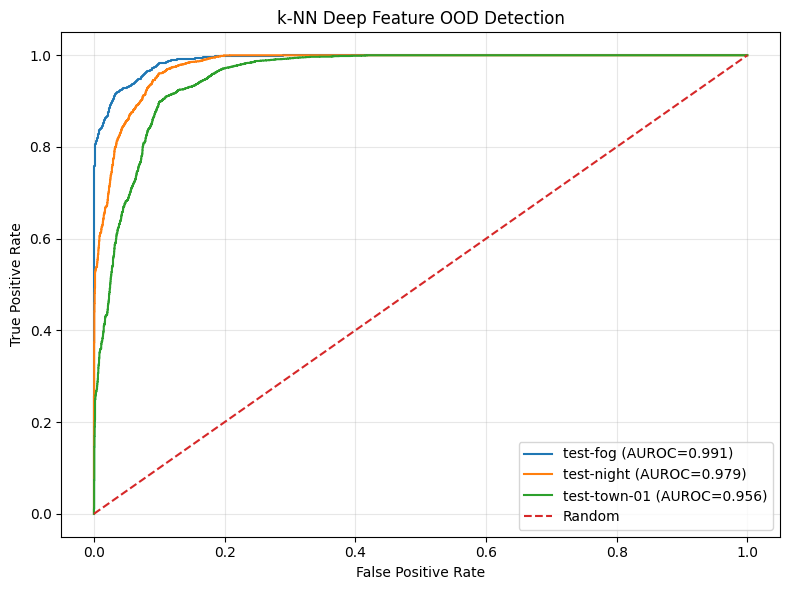


k-NN OOD DETECTION COMPLETE
Results saved to: E:\ML_Safety\ood_results\knn_features\knn_ood_auroc_results.csv
ROC plot saved to: E:\ML_Safety\ood_results\knn_features\knn_ood_roc_curves.png

CELL 10 COMPLETE


In [12]:
# ============================================================
# EXERCISE 9.7 - k-NN OOD DETECTION AUROC
# CELL 10
# ============================================================

print("=" * 70)
print("EXERCISE 9.7 - k-NN OOD DETECTION AUROC")
print("=" * 70)


# ============================================================
# IMPORTS
# ============================================================

from sklearn.metrics import (
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import pandas as pd
import os
import numpy as np


# ============================================================
# CONFIGURATION
# ============================================================

ID_CONDITION = "test"

OOD_CONDITIONS = [
    "test-fog",
    "test-night",
    "test-town-01"
]


# ============================================================
# VERIFY SCORES
# ============================================================

print("\n" + "-" * 70)
print("SCORE VERIFICATION")
print("-" * 70)

for condition in [ID_CONDITION] + OOD_CONDITIONS:

    if condition not in knn_scores:

        raise KeyError(
            f"k-NN scores not found for: {condition}"
        )

    print(
        f"{condition:15s} | "
        f"Samples={len(knn_scores[condition])}"
    )


# ============================================================
# CALCULATE AUROC
# ============================================================

results = []

roc_data = {}


id_scores = knn_scores[
    ID_CONDITION
]


for ood_condition in OOD_CONDITIONS:

    print("\n" + "=" * 70)

    print(
        f"OOD DETECTION: {ood_condition}"
    )

    print("=" * 70)


    ood_scores = knn_scores[
        ood_condition
    ]


    # --------------------------------------------------------
    # Labels
    #
    # 0 = ID
    # 1 = OOD
    # --------------------------------------------------------

    y_true = np.concatenate([
        np.zeros(
            len(id_scores),
            dtype=int
        ),
        np.ones(
            len(ood_scores),
            dtype=int
        )
    ])


    # --------------------------------------------------------
    # k-NN distance is the anomaly score.
    #
    # Larger distance = more likely OOD.
    # --------------------------------------------------------

    y_score = np.concatenate([
        id_scores,
        ood_scores
    ])


    # --------------------------------------------------------
    # AUROC
    # --------------------------------------------------------

    auroc = roc_auc_score(
        y_true,
        y_score
    )


    # --------------------------------------------------------
    # ROC CURVE
    # --------------------------------------------------------

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_score
    )


    roc_data[
        ood_condition
    ] = {
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds
    }


    # --------------------------------------------------------
    # Statistics
    # --------------------------------------------------------

    id_mean = np.mean(
        id_scores
    )

    ood_mean = np.mean(
        ood_scores
    )

    id_median = np.median(
        id_scores
    )

    ood_median = np.median(
        ood_scores
    )


    print(
        f"ID condition    : {ID_CONDITION}"
    )

    print(
        f"OOD condition   : {ood_condition}"
    )

    print(
        f"ID mean distance  : {id_mean:.6f}"
    )

    print(
        f"OOD mean distance : {ood_mean:.6f}"
    )

    print(
        f"ID median distance  : {id_median:.6f}"
    )

    print(
        f"OOD median distance : {ood_median:.6f}"
    )

    print(
        f"AUROC           : {auroc:.4f}"
    )


    results.append([
        "Traffic Light",
        ID_CONDITION,
        ood_condition,
        id_mean,
        ood_mean,
        id_median,
        ood_median,
        auroc
    ])


# ============================================================
# RESULTS DATAFRAME
# ============================================================

knn_auroc_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "ID Condition",
        "OOD Condition",
        "ID Mean Distance",
        "OOD Mean Distance",
        "ID Median Distance",
        "OOD Median Distance",
        "AUROC"
    ]
)


print("\n" + "=" * 70)
print("k-NN OOD DETECTION SUMMARY")
print("=" * 70)

display(
    knn_auroc_df
)


# ============================================================
# PLOT ROC CURVES
# ============================================================

plt.figure(
    figsize=(8, 6)
)


for condition, data in roc_data.items():

    auroc = knn_auroc_df.loc[
        knn_auroc_df["OOD Condition"] == condition,
        "AUROC"
    ].iloc[0]

    plt.plot(
        data["fpr"],
        data["tpr"],
        label=(
            f"{condition} "
            f"(AUROC={auroc:.3f})"
        )
    )


# Random baseline

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "k-NN Deep Feature OOD Detection"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


# ============================================================
# SAVE PLOT
# ============================================================

knn_roc_path = os.path.join(
    knn_output_dir,
    "knn_ood_roc_curves.png"
)

plt.savefig(
    knn_roc_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# SAVE RESULTS
# ============================================================

knn_auroc_path = os.path.join(
    knn_output_dir,
    "knn_ood_auroc_results.csv"
)

knn_auroc_df.to_csv(
    knn_auroc_path,
    index=False
)


# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("k-NN OOD DETECTION COMPLETE")
print("=" * 70)

print(
    "Results saved to:",
    knn_auroc_path
)

print(
    "ROC plot saved to:",
    knn_roc_path
)

print("\nCELL 10 COMPLETE")
print("=" * 70)

EXERCISE 9.7 - k-NN DISTANCE DISTRIBUTIONS

----------------------------------------------------------------------
DISTANCE STATISTICS
----------------------------------------------------------------------
test            | Mean=0.261962 | Median=0.239967 | Std=0.117235
test-fog        | Mean=0.619637 | Median=0.637554 | Std=0.070772
test-night      | Mean=0.577096 | Median=0.575745 | Std=0.083310
test-town-01    | Mean=0.516706 | Median=0.523477 | Std=0.068034


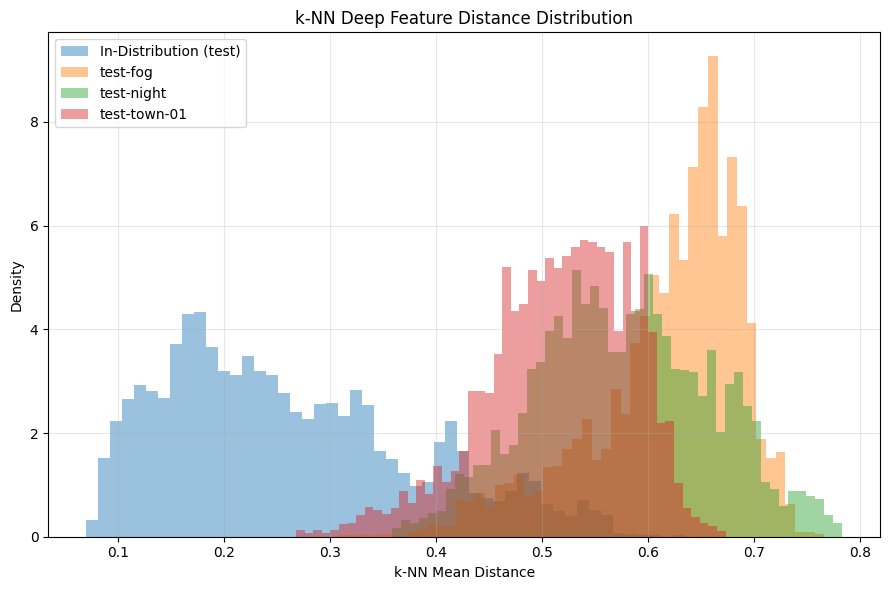

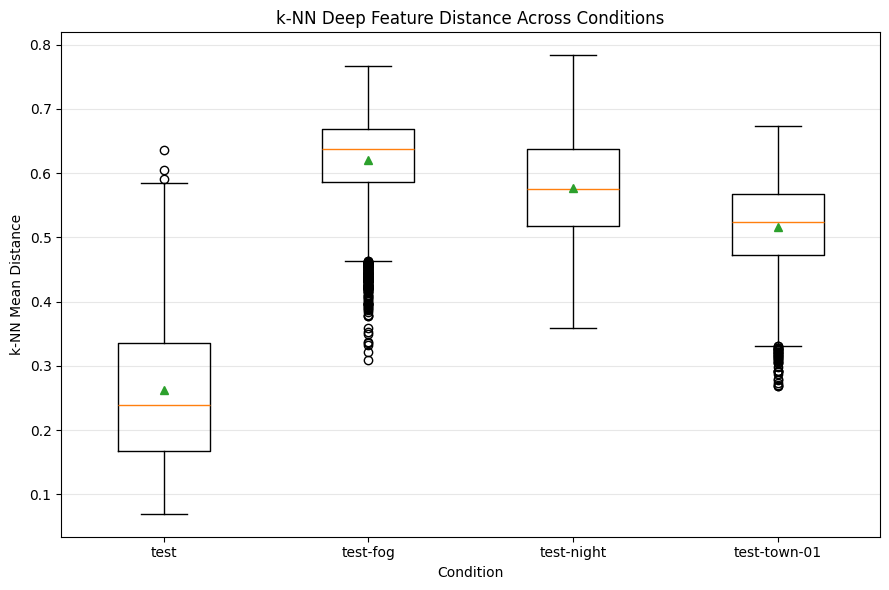


k-NN DISTANCE DISTRIBUTION ANALYSIS COMPLETE
Distribution plot saved to: E:\ML_Safety\ood_results\knn_features\knn_distance_distribution.png
Boxplot saved to: E:\ML_Safety\ood_results\knn_features\knn_distance_boxplot.png

CELL 11 COMPLETE


In [13]:
# ============================================================
# EXERCISE 9.7 - k-NN DISTANCE DISTRIBUTIONS
# CELL 11
# ============================================================

print("=" * 70)
print("EXERCISE 9.7 - k-NN DISTANCE DISTRIBUTIONS")
print("=" * 70)


# ============================================================
# IMPORTS
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import os


# ============================================================
# OUTPUT DIRECTORY
# ============================================================

knn_distribution_dir = os.path.join(
    OOD_RESULTS_DIR,
    "knn_features"
)

os.makedirs(
    knn_distribution_dir,
    exist_ok=True
)


# ============================================================
# DISPLAY STATISTICS
# ============================================================

print("\n" + "-" * 70)
print("DISTANCE STATISTICS")
print("-" * 70)

for condition in [
    "test",
    "test-fog",
    "test-night",
    "test-town-01"
]:

    scores = knn_scores[condition]

    print(
        f"{condition:15s} | "
        f"Mean={np.mean(scores):.6f} | "
        f"Median={np.median(scores):.6f} | "
        f"Std={np.std(scores):.6f}"
    )


# ============================================================
# INDIVIDUAL DISTRIBUTION PLOT
# ============================================================

plt.figure(
    figsize=(9, 6)
)

conditions = [
    "test",
    "test-fog",
    "test-night",
    "test-town-01"
]

labels = {
    "test": "In-Distribution (test)",
    "test-fog": "test-fog",
    "test-night": "test-night",
    "test-town-01": "test-town-01"
}

for condition in conditions:

    scores = knn_scores[condition]

    plt.hist(
        scores,
        bins=50,
        density=True,
        alpha=0.45,
        label=labels[condition]
    )


plt.xlabel(
    "k-NN Mean Distance"
)

plt.ylabel(
    "Density"
)

plt.title(
    "k-NN Deep Feature Distance Distribution"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


# ============================================================
# SAVE INDIVIDUAL PLOT
# ============================================================

distribution_path = os.path.join(
    knn_distribution_dir,
    "knn_distance_distribution.png"
)

plt.savefig(
    distribution_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# ID VS OOD BOXPLOT
# ============================================================

plt.figure(
    figsize=(9, 6)
)

box_data = [
    knn_scores["test"],
    knn_scores["test-fog"],
    knn_scores["test-night"],
    knn_scores["test-town-01"]
]

box_labels = [
    "test",
    "test-fog",
    "test-night",
    "test-town-01"
]

plt.boxplot(
    box_data,
    labels=box_labels,
    showmeans=True
)

plt.ylabel(
    "k-NN Mean Distance"
)

plt.xlabel(
    "Condition"
)

plt.title(
    "k-NN Deep Feature Distance Across Conditions"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()


# ============================================================
# SAVE BOXPLOT
# ============================================================

boxplot_path = os.path.join(
    knn_distribution_dir,
    "knn_distance_boxplot.png"
)

plt.savefig(
    boxplot_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FINAL OUTPUT
# ============================================================

print("\n" + "=" * 70)
print("k-NN DISTANCE DISTRIBUTION ANALYSIS COMPLETE")
print("=" * 70)

print(
    "Distribution plot saved to:",
    distribution_path
)

print(
    "Boxplot saved to:",
    boxplot_path
)

print("\nCELL 11 COMPLETE")
print("=" * 70)

In [14]:
# ============================================================
# EXERCISE 9.7 - FINAL OOD METHOD COMPARISON
# CELL 12
# ============================================================

print("=" * 70)
print("EXERCISE 9.7 - FINAL OOD METHOD COMPARISON")
print("=" * 70)


# ============================================================
# MSP RESULTS FROM EXERCISE 9.4
# ============================================================

msp_results = pd.DataFrame([
    ["Pedestrian", "test-fog", 0.4041],
    ["Pedestrian", "test-night", 0.6823],

    ["Traffic Light", "test-fog", 0.8846],
    ["Traffic Light", "test-night", 0.4773],

    ["Vehicle", "test-fog", 0.7347],
    ["Vehicle", "test-night", 0.7352],
], columns=[
    "Model",
    "OOD Condition",
    "MSP AUROC"
])


# ============================================================
# k-NN RESULTS
# ============================================================

knn_comparison = knn_auroc_df[
    [
        "Model",
        "OOD Condition",
        "AUROC"
    ]
].copy()

knn_comparison = knn_comparison.rename(
    columns={
        "AUROC": "k-NN AUROC"
    }
)


# ============================================================
# TRAFFIC LIGHT COMPARISON
# ============================================================

traffic_msp = msp_results[
    msp_results["Model"] == "Traffic Light"
].copy()

traffic_knn = knn_comparison[
    knn_comparison["Model"] == "Traffic Light"
].copy()


comparison_df = pd.merge(
    traffic_msp,
    traffic_knn,
    on=[
        "Model",
        "OOD Condition"
    ],
    how="outer"
)


comparison_df[
    "AUROC Improvement"
] = (
    comparison_df["k-NN AUROC"]
    -
    comparison_df["MSP AUROC"]
)


print("\n" + "=" * 70)
print("MSP VS k-NN OOD DETECTION")
print("=" * 70)

display(
    comparison_df
)


# ============================================================
# k-NN RESULTS INCLUDING TOWN
# ============================================================

print("\n" + "=" * 70)
print("k-NN PERFORMANCE ACROSS ALL CONDITIONS")
print("=" * 70)

display(
    knn_auroc_df
)


# ============================================================
# BEST k-NN CONDITION
# ============================================================

best_knn = knn_auroc_df.loc[
    knn_auroc_df["AUROC"].idxmax()
]

print("\n" + "-" * 70)
print("BEST k-NN OOD DETECTION")
print("-" * 70)

print(
    f"OOD condition : "
    f"{best_knn['OOD Condition']}"
)

print(
    f"AUROC         : "
    f"{best_knn['AUROC']:.4f}"
)


# ============================================================
# WORST k-NN CONDITION
# ============================================================

worst_knn = knn_auroc_df.loc[
    knn_auroc_df["AUROC"].idxmin()
]

print("\n" + "-" * 70)
print("LOWEST k-NN OOD DETECTION")
print("-" * 70)

print(
    f"OOD condition : "
    f"{worst_knn['OOD Condition']}"
)

print(
    f"AUROC         : "
    f"{worst_knn['AUROC']:.4f}"
)


# ============================================================
# MEAN k-NN AUROC
# ============================================================

mean_knn_auroc = (
    knn_auroc_df["AUROC"].mean()
)

print("\n" + "-" * 70)
print("MEAN k-NN AUROC")
print("-" * 70)

print(
    f"Mean AUROC : "
    f"{mean_knn_auroc:.4f}"
)


# ============================================================
# MEAN MSP AUROC
# ============================================================

traffic_msp_mean = (
    traffic_msp["MSP AUROC"].mean()
)

traffic_knn_mean = (
    traffic_knn["k-NN AUROC"].mean()
)

print("\n" + "-" * 70)
print("TRAFFIC LIGHT METHOD COMPARISON")
print("-" * 70)

print(
    f"Mean MSP AUROC : "
    f"{traffic_msp_mean:.4f}"
)

print(
    f"Mean k-NN AUROC : "
    f"{traffic_knn_mean:.4f}"
)

print(
    f"Mean improvement : "
    f"{traffic_knn_mean - traffic_msp_mean:.4f}"
)


# ============================================================
# FINAL INTERPRETATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL INTERPRETATION")
print("=" * 70)

print(
    "\n1. The k-NN deep-feature method separates "
    "the ID test distribution from the shifted "
    "conditions very effectively."
)

print(
    "\n2. The largest k-NN AUROC was observed for "
    f"{best_knn['OOD Condition']} "
    f"({best_knn['AUROC']:.4f})."
)

print(
    "\n3. The lowest k-NN AUROC among the evaluated "
    f"conditions was {worst_knn['OOD Condition']} "
    f"({worst_knn['AUROC']:.4f})."
)

print(
    "\n4. Deep feature distance provides a strong "
    "OOD signal because shifted images are farther "
    "from the training feature distribution."
)

print(
    "\n5. For the Traffic Light model, k-NN deep "
    "features outperform MSP for both fog and "
    "night OOD detection."
)


# ============================================================
# SAVE FINAL COMPARISON
# ============================================================

comparison_path = os.path.join(
    knn_output_dir,
    "msp_vs_knn_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)


print("\n" + "=" * 70)
print("FINAL OOD COMPARISON COMPLETE")
print("=" * 70)

print(
    "Comparison saved to:",
    comparison_path
)

print("\nCELL 12 COMPLETE")
print("=" * 70)

EXERCISE 9.7 - FINAL OOD METHOD COMPARISON

MSP VS k-NN OOD DETECTION


,Model,OOD Condition,MSP AUROC,k-NN AUROC,AUROC Improvement
0,Traffic Light,test-fog,0.8846,0.990734,0.106134
1,Traffic Light,test-night,0.4773,0.979480,0.502180
2,Traffic Light,test-town-01,NaN,0.955629,NaN



k-NN PERFORMANCE ACROSS ALL CONDITIONS


,Model,ID Condition,OOD Condition,ID Mean Distance,OOD Mean Distance,ID Median Distance,OOD Median Distance,AUROC
0,Traffic Light,test,test-fog,0.261962,0.619637,0.239967,0.637554,0.990734
1,Traffic Light,test,test-night,0.261962,0.577096,0.239967,0.575745,0.979480
2,Traffic Light,test,test-town-01,0.261962,0.516706,0.239967,0.523477,0.955629



----------------------------------------------------------------------
BEST k-NN OOD DETECTION
----------------------------------------------------------------------
OOD condition : test-fog
AUROC         : 0.9907

----------------------------------------------------------------------
LOWEST k-NN OOD DETECTION
----------------------------------------------------------------------
OOD condition : test-town-01
AUROC         : 0.9556

----------------------------------------------------------------------
MEAN k-NN AUROC
----------------------------------------------------------------------
Mean AUROC : 0.9753

----------------------------------------------------------------------
TRAFFIC LIGHT METHOD COMPARISON
----------------------------------------------------------------------
Mean MSP AUROC : 0.6810
Mean k-NN AUROC : 0.9753
Mean improvement : 0.2943

FINAL INTERPRETATION

1. The k-NN deep-feature method separates the ID test distribution from the shifted conditions very effectively.